In [203]:
import os
import sys

PROJECT_NAME = 'june-2026'

try:

    from google.colab import drive
    drive.mount('/content/drive')

    PROJECT_ROOT = f'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in Google Colab.")

except:

    PROJECT_ROOT = rf'D:/Data-Science/Practice/PnT/{PROJECT_NAME}'

    print("Running in local environment.")

# Move to project root
os.chdir(PROJECT_ROOT)

print("Current working directory:", os.getcwd())

# Add project root to Python path
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

Running in local environment.
Current working directory: D:\Data-Science\Practice\PnT\june-2026


In [204]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


In [205]:
df = sns.load_dataset("iris")
df.shape

(150, 5)

In [206]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [207]:
df.tail()

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica
149,5.9,3.0,5.1,1.8,virginica


In [208]:
df.sample()

,sepal_length,sepal_width,petal_length,petal_width,species
20,5.4,3.4,1.7,0.2,setosa


In [209]:
df.dtypes

sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

In [210]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [211]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [212]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [213]:
df.nunique()

sepal_length    35
sepal_width     23
petal_length    43
petal_width     22
species          3
dtype: int64

In [214]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [215]:
df.min(numeric_only=True)

sepal_length    4.3
sepal_width     2.0
petal_length    1.0
petal_width     0.1
dtype: float64

In [216]:
df.max(numeric_only=True)

sepal_length    7.9
sepal_width     4.4
petal_length    6.9
petal_width     2.5
dtype: float64

In [217]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [218]:
df["sepal_length"] = df["sepal_length"].fillna(df["sepal_length"].mean())

In [219]:
#df = df.drop(columns=["sepal_length", "sepal_width"])
df = df.dropna(subset=["sepal_length"])

In [220]:
df = df.dropna(subset=["sepal_length"])
df = df.dropna(subset=["petal_length"])

In [221]:
df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [222]:
df["species"] = df["species"].astype("category")

In [223]:
df.dtypes

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

In [224]:
my_table = pd.DataFrame()
numeric_cols = df.select_dtypes(np.number).columns

my_table["Mean"] = df[numeric_cols].mean()
my_table["Mode"] = df[numeric_cols].mode().iloc[0]
my_table["Median"] = df[numeric_cols].median()
my_table["Variance"] = df[numeric_cols].var()
my_table["STD"] = df[numeric_cols].std()
my_table["Min"] = df[numeric_cols].min()
my_table["Max"] = df[numeric_cols].max()
my_table["Q1"] = df[numeric_cols].quantile(.25)
my_table["Q3"] = df[numeric_cols].quantile(.75)
my_table["IQR"] = my_table["Q3"] - my_table["Q1"]
my_table["Upper Bound"] = my_table["Q3"] + (1.5 * my_table["IQR"])
my_table["Lower Bound"] = my_table["Q1"] - (1.5 * my_table["IQR"])

my_table

,Mean,Mode,Median,Variance,STD,Min,Max,Q1,Q3,IQR,Upper Bound,Lower Bound
sepal_length,5.843333,5.0,5.80,0.685694,0.828066,4.3,7.9,5.1,6.4,1.3,8.35,3.15
sepal_width,3.057333,3.0,3.00,0.189979,0.435866,2.0,4.4,2.8,3.3,0.5,4.05,2.05
petal_length,3.758000,1.4,4.35,3.116278,1.765298,1.0,6.9,1.6,5.1,3.5,10.35,-3.65
petal_width,1.199333,0.2,1.30,0.581006,0.762238,0.1,2.5,0.3,1.8,1.5,4.05,-1.95


In [225]:
numeric_columns = df[["sepal_length", "sepal_width", "petal_length", "petal_width"]].columns

my_df = pd.DataFrame()

my_df["Mean"] = df[numeric_columns].mean()
my_df["Mode"] = df[numeric_columns].mode().iloc[0]
my_df

,Mean,Mode
sepal_length,5.843333,5.0
sepal_width,3.057333,3.0
petal_length,3.758000,1.4
petal_width,1.199333,0.2


In [226]:
population_mean = df["sepal_length"].mean()
sam_mean = df["sepal_length"].sample(n=30, random_state=42)

print(f"Population mean: {population_mean:.2f}")
print(f"Sample mean: {sam_mean.mean():.2f}")

Population mean: 5.84
Sample mean: 5.98


<Axes: xlabel='sepal_length', ylabel='Count'>

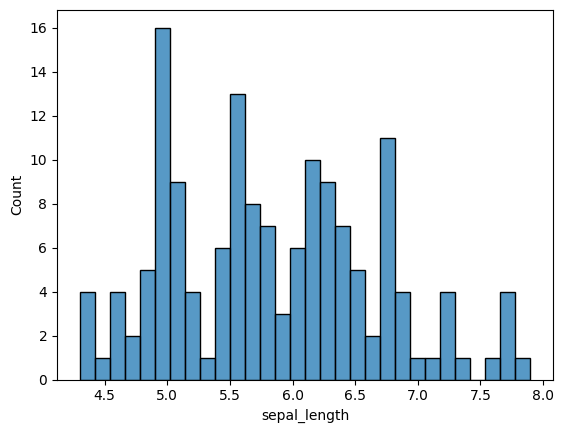

In [230]:
sns.histplot(df["sepal_length"], bins=30)

In [227]:
sample_mean = []

for i in range(1000):
    sample = df["sepal_length"].sample(n=30, replace=True)
    sample_mean.append(sample.mean())

sample_mean = np.array(sample_mean)
mean_of_sample_mean = sample_mean.mean()

print(f"Population mean: {population_mean:.2f}")
print(f"Sample mean: {mean_of_sample_mean:.2f}")

Population mean: 5.84
Sample mean: 5.84


<Axes: ylabel='Count'>

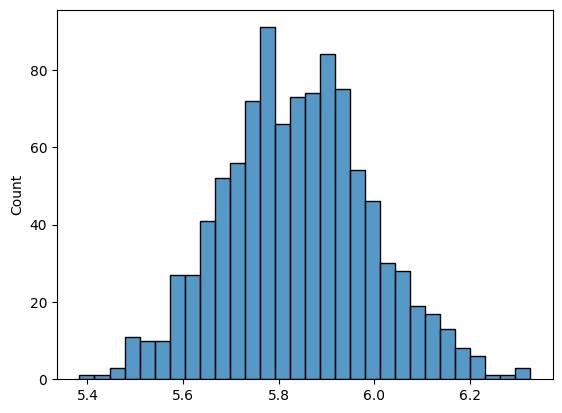

In [232]:
sns.histplot(sample_mean, bins=30)

In [233]:
df.dtypes

sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

In [237]:
x = df["sepal_length"]
y = df["petal_length"]

cov = x.cov(y)

if cov > 0:
    print("Positive Covariance")
elif cov == 0:
    print("No Covariance")
else:
    print("Negative covariance")


print(f"Covariance: {cov:.2f}")

Positive Covariance
Covariance: 1.27


In [239]:
df["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [241]:
group_1 = df[df["species"] == "virginica"]["sepal_length"]
group_2 = df[df["species"] == "setosa"]["sepal_length"]

t_stat, p_value = stats.ttest_ind(group_1, group_2)

print(t_stat, p_value)

alpha = .05

if p_value < alpha:
    print("Reject the H0")
else:
    print("Fail to reject H0")

15.386195820079404 6.892546060674143e-28
Reject the H0


In [243]:
#CI = Mean +/- Z * STD/squr(n)

sample = df["sepal_length"].sample(n=30, random_state=42)
sample_mean = sample.mean()
n = len(df)
std = df["sepal_length"].std()
SE = std/np.sqrt(n)
ME = 1.96 * SE
CI95_lower = sample_mean - ME
CI95_upper = sample_mean + ME

print(CI95_lower, CI95_upper)

5.847481820193908 6.112518179806093


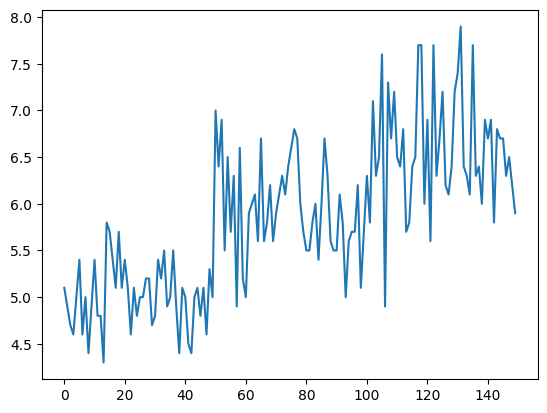

In [245]:
plt.plot(df["sepal_length"])
plt.show()

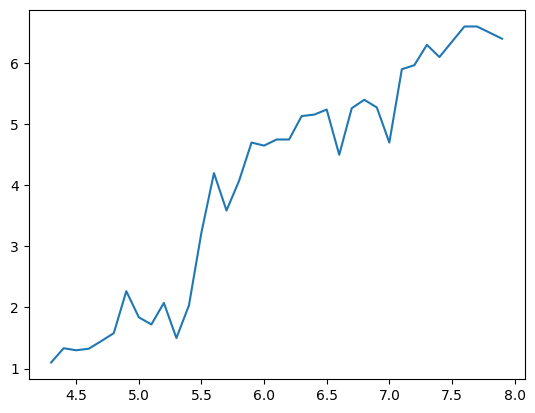

In [246]:
x = df.groupby(df["sepal_length"])["petal_length"].mean()

plt.plot(x.index, x.values)

<Axes: xlabel='sepal_length', ylabel='count'>

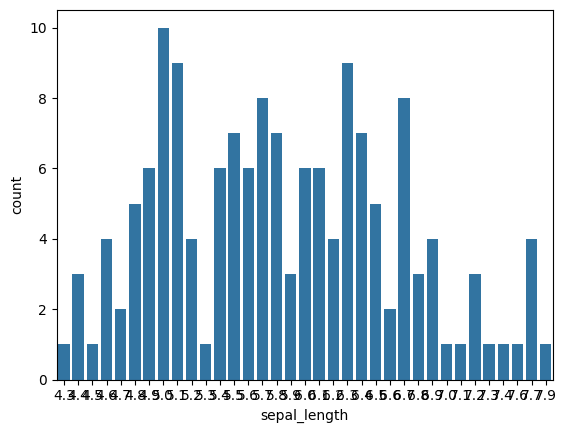

In [252]:
sns.countplot(x = "sepal_length", data=df)

<Axes: xlabel='sepal_length', ylabel='Count'>

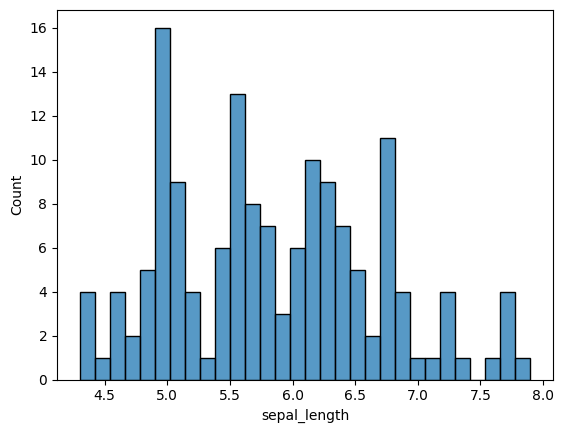

In [257]:
sns.histplot(x="sepal_length", bins=30, data=df)

([<matplotlib.patches.Wedge at 0x25f2ad996d0>,
 [Text(0.5499999722395388, 0.9526279601903919, ''),
  Text(-1.0999999999999959, -9.616505800409723e-08, ''),
  Text(0.5500003659264656, -0.9526277328950455, '')])

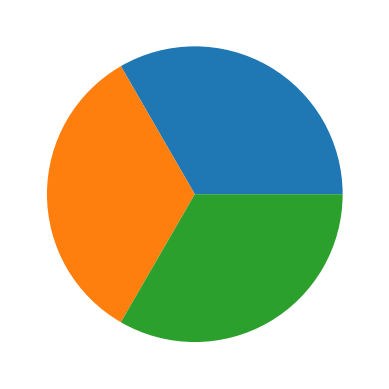

In [262]:
plt.pie(df["species"].value_counts())

<Axes: xlabel='sepal_length'>

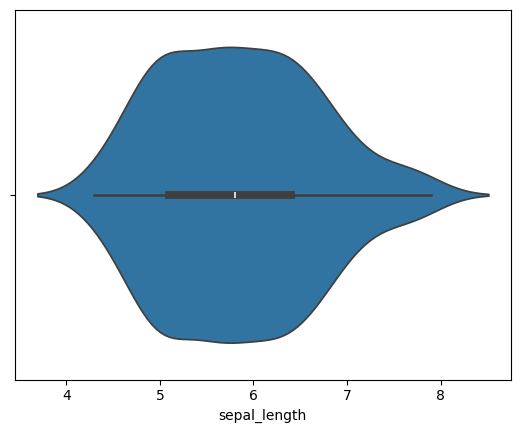

In [264]:
sns.violinplot(x = "sepal_length", data=df)

<Axes: xlabel='sepal_length'>

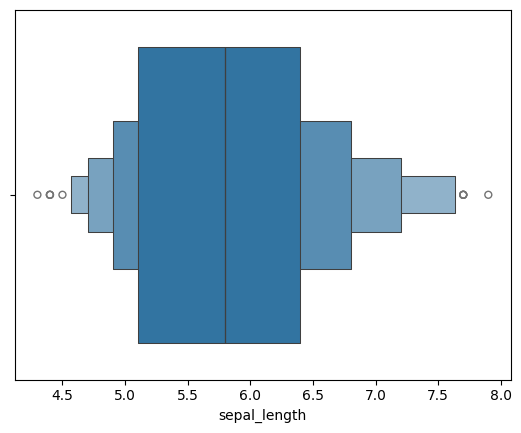

In [265]:
sns.boxenplot(x = "sepal_length", data=df)

<Axes: >

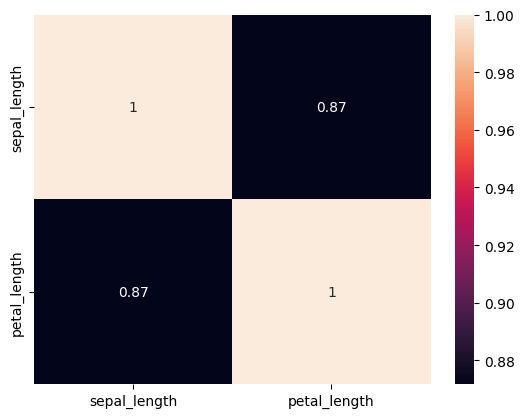

In [267]:
sns.heatmap(df[["sepal_length", "petal_length"]].corr(), annot=True)

<Axes: >

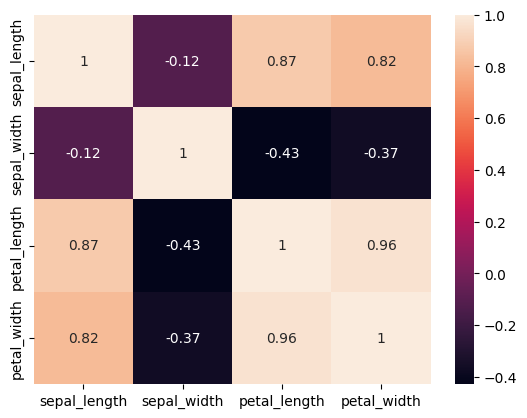

In [270]:
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)

<Axes: xlabel='petal_length', ylabel='petal_width'>

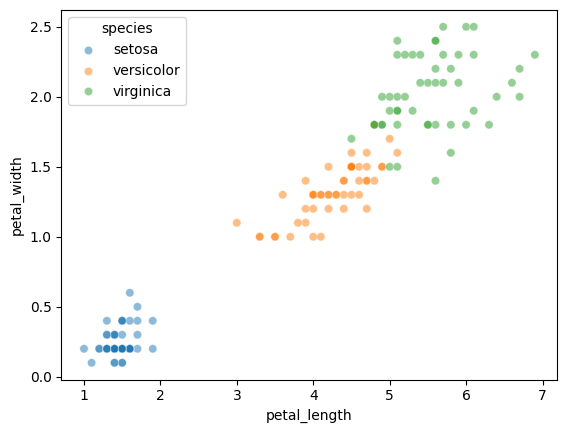

In [280]:
sns.scatterplot(x = "petal_length", y= "petal_width", alpha = .5, hue="species", data=df)